In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler,PolynomialFeatures

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
x = 6* np.random.rand(200,1) - 3
y = 0.8*x**2 + 0.9*x + 2 + np.random.rand(200,1)

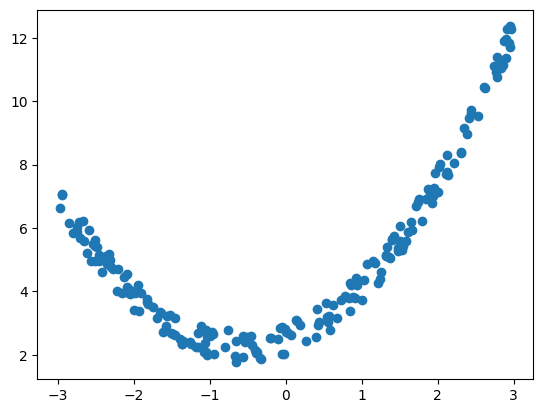

In [3]:
plt.scatter(x,y)

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
lr = LinearRegression()

In [6]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred = lr.predict(x_test)

In [8]:
r2_score(y_test,y_pred)

0.3418713740225263

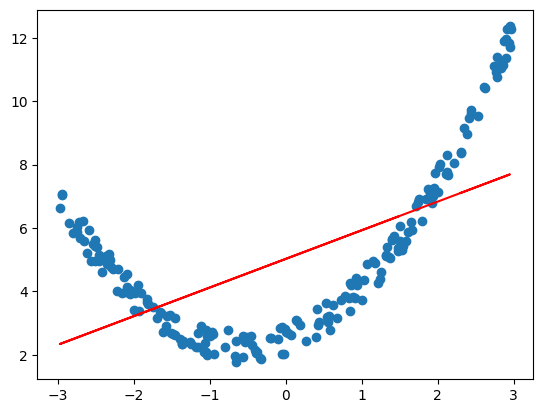

In [9]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.scatter(x,y)

In [10]:
poly = PolynomialFeatures(degree=2)

In [11]:
x_train_trf = poly.fit_transform(x_train)
x_test_trf = poly.transform(x_test)

In [12]:
print(x_train[0]) #x^1
print(x_train_trf[0]) # x^0  x^1  x^2

[1.47304951]
[1.         1.47304951 2.16987486]


In [13]:
lr.fit(x_train_trf,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(x_test_trf)

In [15]:
r2_score(y_test,y_pred)

0.9858243145405317

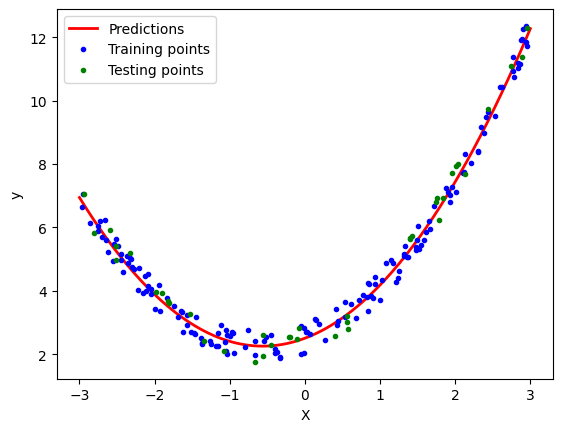

In [16]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [17]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(x, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

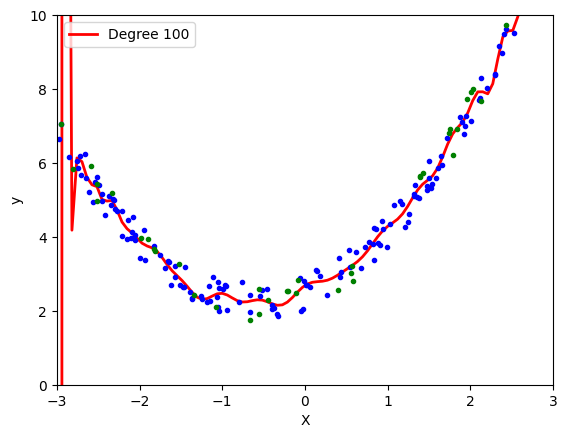

In [18]:
polynomial_regression(100)

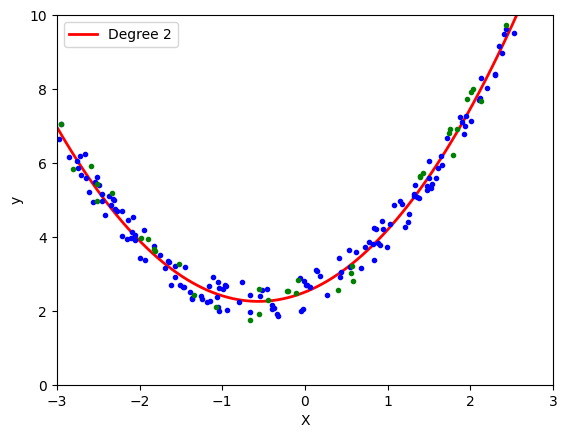

In [19]:
polynomial_regression(2)

In [20]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [23]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [24]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [25]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [26]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [43]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)
print("Input",poly.n_features_in_)
print("Ouput",poly.n_features_in_)
print("Powers\n",poly.powers_)

Input 2
Ouput 2
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [44]:
X_multi_trans.shape

(100, 6)

In [45]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
X_test_multi = poly.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

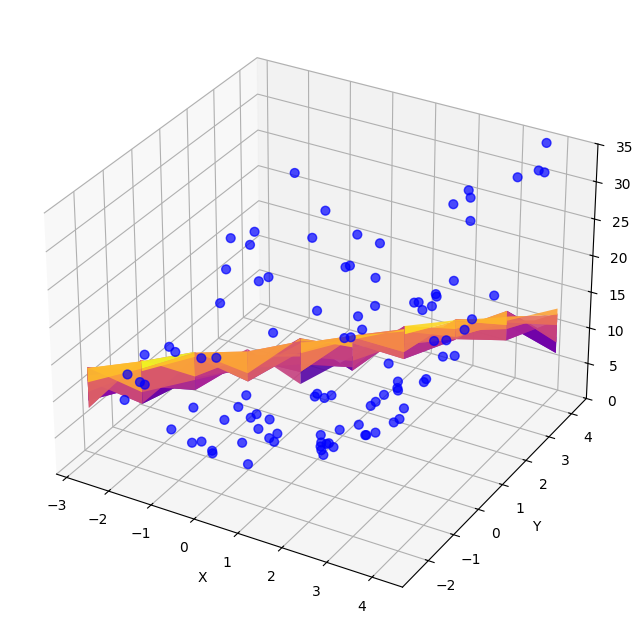

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D projections

# Initialize the figure and a 3D subplot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot the Scatter points (equivalent to px.scatter_3d)
# Adjust 'c' (color), 's' (size), and 'alpha' (transparency) as needed
scatter = ax.scatter(
    x.ravel(), 
    y.ravel(), 
    z.ravel(), 
    c='blue', 
    s=40, 
    alpha=0.7, 
    label='Data Points'
)

# 2. Plot the Surface (equivalent to go.Surface)
# Using the 'plasma' or 'inferno' colormap closely matches your Plotly look
surface = ax.plot_surface(
    x_input, 
    y_input, 
    z_final, 
    cmap='plasma', 
    alpha=0.9, 
    antialiased=True
)

# 3. Match the Layout and Z-Axis constraints
ax.set_zlim(0, 35)

# Label the axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Optional: Add a colorbar for the surface plot gradient
# fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10)

# Display the static 3D plot
plt.show()

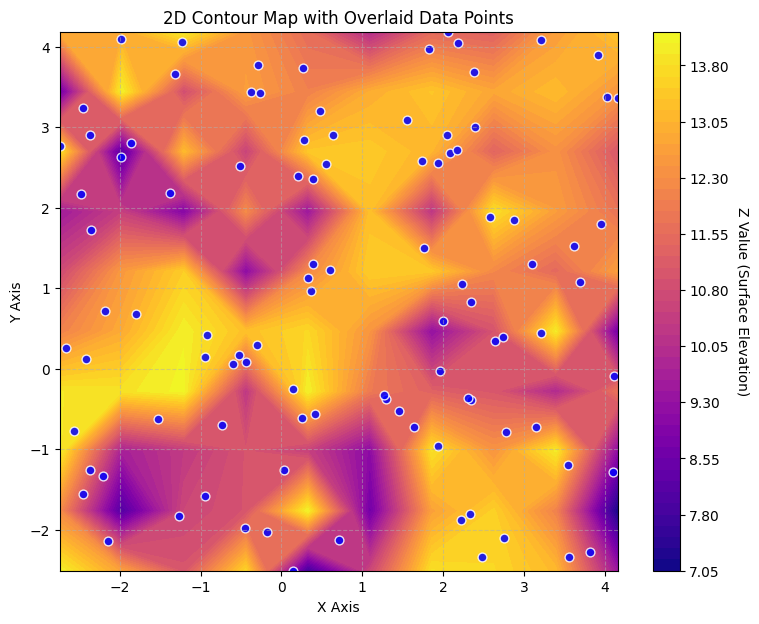

In [51]:
fig, ax = plt.subplots(figsize=(9, 7))

# 1. Plot the Surface as a 2D Filled Contour Map
# This translates the 3D surface into a 2D colored topography map
contour = ax.contourf(
    x_input, 
    y_input, 
    z_final, 
    levels=50,       # Smoothness of the color transitions
    cmap='plasma'    # Matches your original Plotly surface colors
)

# 2. Overlay the Scatter Points
# Plotted using X and Y coordinates on the 2D plane
scatter = ax.scatter(
    x.ravel(), 
    y.ravel(), 
    c='blue',        # Solid blue dots to match your original visual
    s=40, 
    edgecolors='white', # Helps the blue dots pop out against the background
    alpha=0.85,
    label='Data Points'
)

# 3. Add a Colorbar to explain what the background colors mean (Z-values)
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Z Value (Surface Elevation)', rotation=270, labelpad=15)

# Set Axis Labels
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title('2D Contour Map with Overlaid Data Points')

# Optional: Add gridlines for readability
ax.grid(True, linestyle='--', alpha=0.5)

# Display the 2D plot
plt.show()